# **Modeling caustics using simple polynomial models of Whitney's singularities**


* **Python 3.12 Jupyter notebook**
* **author=Mikołaj Korzyński**

The idea is to model lensing maps using the polynomial expression from the papers [Gaudi, Petters 2002a], [Gaudi, Petter 2002b] and [Congdon, Keeton, Nordgren 2008].


---
## **0. Imports, classes, definitions**

### **0.1 Imports**

In [1]:
import numpy as np
import scipy as sp
import matplotlib as mpl
from matplotlib import pyplot as plt
import astropy
from astropy import units as u
from typing import Callable, Any

### **0.2 Functions**

In [2]:
def clamp(a, lo, hi):
    return min(max(lo, a), hi)

### **0.3 Classes**

In [3]:
class AbstractLens:
    pass


---
## **1. Cusp**

$$u_1 = c\,\theta_1 + \frac{b}{2}\,\theta_2^2$$
$$u_2 = b\,\theta_1\,\theta_2 + a\,\theta_2^3$$

Here the dimension is:
* $[u_1] = [u_2] = [\theta_1] = [\theta_2] = {\rm rad}$
* $[c] = 1$
* $[b] = {\rm rad}^{-1}$
* $[a] = {\rm rad}^{-2}$.

**We introduce dimensionless variables**

$a =: \theta_*^{-2}$, where $\theta_*$ measures the angular size of the cusp ($[\theta_*] = {\rm rad}$).

Introduce dimensionless variables:
$$V_A:=\frac{\theta_A}{\theta_*}$$
$$U_A:=\frac{\theta_A}{\theta_*}$$
$$B:=b\,\theta_*$$
$$C:=c$$

The lensing equation takes the form of:

$$U_1 = C\,V_1 + \frac{B}{2}\,{V_2}^2$$
$$U_2 = B\,V_1\,V_2 + {V_2}^3$$

Assume we have a line in the source plane:
$$ \cos\varphi\,U_1 + \sin\varphi\,U_2 = \gamma$$

Substituting the lensing equation, we get on the lens plane the following:
$$\gamma = \sin\varphi\,{V_2}^3 + \cos\varphi\,\frac{B}{2}\,{V_2}^2 + B\,\sin\varphi\,V_1\,V_2 + C\,\cos\varphi\,V_1$$

**Idea:** make a contour plot of the function

$$\gamma_{\varphi,B,C}(V_1, V_2) = \sin\varphi\,{V_2}^3 + \cos\varphi\,\frac{B}{2}\,{V_2}^2 + B\,\sin\varphi\,V_1\,V_2 + C\,\cos\varphi\,V_1$$
in order to see what happens to the gradient of intensity near the cusp

### **1.1 Define the CuspLens class**

In [4]:
class CuspLens(AbstractLens):
    def __init__(self, *, b: float, c: float, a: float = 1., name: str = "Cusp Lens") -> None:
        self.a = a
        self.b = b
        self.c = c
        self.name = name
        return
    
    '''Encodes the lensing map (theta1, theta2) -> (u1, u2)'''
    def lensing_map(self, theta1: np.typing.NDArray, theta2: np.typing.NDArray) -> Any:
        u1 = self.c * theta1 + self.b / 2 * theta2**2
        u2 = self.b * theta1 * theta2 + self.a * theta2**3
        return u1, u2
    
    '''The Jacobian of the lensing map. Does not work for theta1 and theta2 arrays, only for single values.'''
    def A(self, theta1: float, theta2: float) -> np.typing.NDArray:
        return np.array(
            (self.c,            self.b * theta2),
            (self.b * theta2,   3 * self.a * theta2**2 + self.b * theta1))
    
    '''The determinant of the Jacobian using function A. Does not work for theta1 and theta2 arrays, only for single values.'''
    def detA_using_A(self, theta1: np.typing.NDArray, theta2: np.typing.NDArray) -> Any:
        return np.linalg.det(self.A(theta1, theta2))
    
    '''The determinant of the Jacobian using the formula. Works for arrays.'''
    def detA(self, theta1: np.typing.NDArray, theta2: np.typing.NDArray) -> Any:
        return self.c * (3 * self.a * theta2**2 + self.b * theta1) - (self.b * theta2)**2
    
    
    def gamma_directly(self, phi: float, theta1: np.typing.NDArray, theta2: np.typing.NDArray) -> Any:
        return self.a * np.sin(phi) * theta2**3 + self.b / 2 * np.cos(phi) * theta2**2 + self.b * np.sin(phi) * theta1 * theta2   + np.cos(phi) * self.c * theta1
    

    def gamma(self, phi: float, theta1: np.typing.NDArray, theta2: np.typing.NDArray) -> Any:
        u1, u2 = self.lensing_map(theta1, theta2)
        gamma = np.cos(phi) * u1 + np.sin(phi) * u2
        return gamma    


    


### **1.2 Set up a lens and make a contour plot**

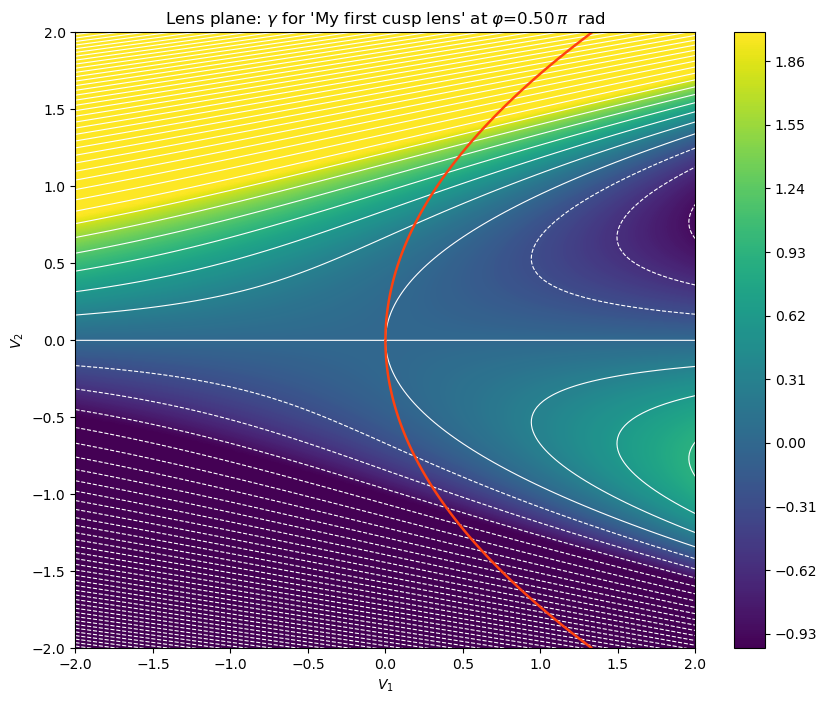

In [5]:
# -----------------------------
#   Define the lensing setup 
# -----------------------------

# --- Define the lens ---
cl = CuspLens(a=1., b=-0.9, c=0.3, name="My first cusp lens")

# --- Incidence angle of the gradient ---
# 0.0 * np.pi = horizontal gradient / vertical stripe
# 0.5 * np.pi = vertical gradient / horizontal stripe
# 0.25 * np.pi = diagonal gradient / diagonal stripe, orthogonal to the gradient direction
phi = 0.5 * np.pi

# --- Clamping interval for gamma ---
lo, hi = (-1., 2.)

# --- Define the grid of V1 and V2 ---
V1_range = (-2., 2.)
N_V1 = 200
V2_range = (-2., 2.)
N_V2 = 200
V1, V2 = np.meshgrid(np.linspace(*V1_range, N_V1), np.linspace(*V2_range, N_V2))


# ----------------------------------------------------------------------------------------------------------------------
#   Make the plot of gamma on the lens plane, with contours of gamma and the critical curve (detA=0) in the same plot.
# ----------------------------------------------------------------------------------------------------------------------

# --- Compute gamma on the grid ---
gamma = cl.gamma(phi=phi, theta1=V1, theta2=V2)

clamped_gamma = np.empty_like(gamma)    # clamped to the range [lo, hi]
for i in range(gamma.shape[0]):
    for j in range(gamma.shape[1]):
        clamped_gamma[i, j] = clamp(gamma[i, j], lo=lo, hi=hi)

# --- Make the plot ---
fig, ax = plt.subplots(figsize=(10, 8))
plt.contourf(V1, V2, clamped_gamma, levels=300, cmap=mpl.colormaps.get_cmap('viridis'), norm=mpl.colors.Normalize(vmin=lo, vmax=hi))
plt.colorbar()
plt.contour(V1, V2, gamma, levels=80, colors='white', linewidths=(0.8,))
critical_contour = plt.contour(     # plot the contour and remember it!
    V1, V2, cl.detA(V1, V2),
    levels=np.array([0.]), colors='xkcd:orangered', linewidths=(1.8,)
)
ax.set_xlabel(r"$V_1$")
ax.set_ylabel(r"$V_2$")
ax.set_title(r"Lens plane: $\gamma$" + f" for '{cl.name}' at " + r"$\varphi$" +  f"={phi/(np.pi):.2f}" + r"$\,\pi$  rad")
plt.show() 

The same plot in the *source plane*

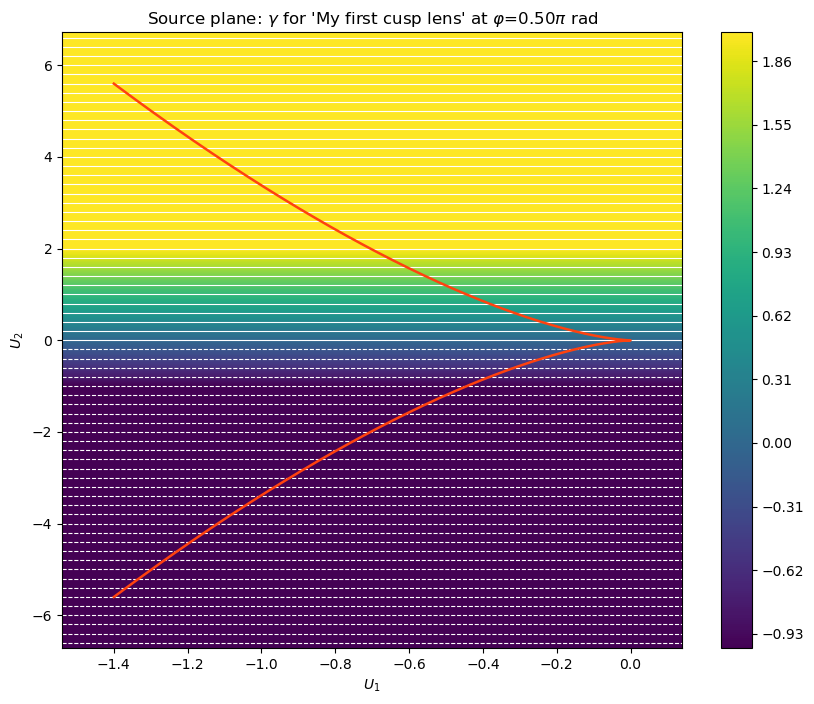

In [6]:
# ---------------------------------------
#   Make the second plot: source plane
# ---------------------------------------

# --- First: extract the critical curve ---
level_set = critical_contour.allsegs[0]     # full level set as a list consisting of many paths (arrays of points)
x_coords = []
y_coords = []
for path in level_set:      # iterate over the paths (connected components of the level set) and extend the list of coordinates
    x_coords.extend(path[:, 0])
    y_coords.extend(path[:, 1])
    
crtitcal_curve = np.stack([np.array(x_coords), np.array(y_coords)], axis=-1)     # make a (N, 2) array

# --- Map the critical curve to the source plane, obtaining this way the caustic ---
caustic_x, caustic_y = cl.lensing_map(crtitcal_curve[:, 0], crtitcal_curve[:, 1])
caustic = np.stack([caustic_x, caustic_y], axis=1)      # make a (N, 2) array

# ---Pick automatically the ranges for the plot on the source plane ---

# # Take the four corners of the plot on the lens plane
# corner00 = [V1_range[0], V2_range[0]]
# corner01 = [V1_range[0], V2_range[1]]
# corner10 = [V1_range[1], V2_range[0]]
# corner11 = [V1_range[1], V2_range[1]]
# corners = np.stack([corner00, corner01, corner10, corner11], axis=0)     # make a (4, 2) array

# # Map them 
# pt_source_plane_U1, pt_source_plane_U2 = cl.lensing_map(corners[:, 0], corners[:, 1])
# pt_source_plane = np.stack([pt_source_plane_U1, pt_source_plane_U2], axis=1)    # make a (N, 2) array

# # Pick the range on the source plane
# U1_range = [min(pt_source_plane[:, 0]), max(pt_source_plane[:, 0])]
# U2_range = [min(pt_source_plane[:, 1]), max(pt_source_plane[:, 1])]

# Ranges containing the caustic
U1_range = [min(caustic_x), max(caustic_x)]
U2_range = [min(caustic_y), max(caustic_y)]

# Extend a little bit the ranges
U1_len = U1_range[1] - U1_range[0]
U2_len = U2_range[1] - U2_range[0]

U1_range = [U1_range[0] - 0.1 * U1_len, U1_range[1] + 0.1 * U1_len]
U2_range = [U2_range[0] - 0.1 * U2_len, U2_range[1] + 0.1 * U2_len]

# --- Prepare the mesh grid ---
N_U1, N_U2 = (200, 200)     # number of points in the grid on the source plane
U1, U2 = np.meshgrid(np.linspace(*U1_range, N_U1), np.linspace(*U2_range, N_U2))

# --- Gamma function ---
gamma_source_plane = U1 * np.cos(phi) + U2 * np.sin(phi)
clamped_gamma_source_plane = np.empty_like(gamma_source_plane)
for i in range(gamma_source_plane.shape[0]):
    for j in range(gamma_source_plane.shape[1]):
        clamped_gamma_source_plane[i, j] = clamp(gamma_source_plane[i, j], lo=lo, hi=hi)


# --- Make the plot ---
fig, ax = plt.subplots(figsize=(10, 8))
plt.contourf(U1, U2, clamped_gamma_source_plane, levels=300, cmap=mpl.colormaps.get_cmap('viridis'), norm=mpl.colors.Normalize(vmin=lo, vmax=hi))
plt.colorbar()
plt.contour(U1, U2, gamma_source_plane, levels=80, colors='white', linewidths=(0.8,))
plt.plot(caustic[:, 0], caustic[:, 1], color='xkcd:orangered', linewidth=1.8)
ax.set_xlabel(r"$U_1$")
ax.set_ylabel(r"$U_2$")
ax.set_title(r"Source plane: $\gamma$" + f" for '{cl.name}' at " + r"$\varphi$" + f"={phi/(np.pi):.2f}" + r"$\pi$ rad")
plt.show() 
plt.show()

Plot along the diagonal

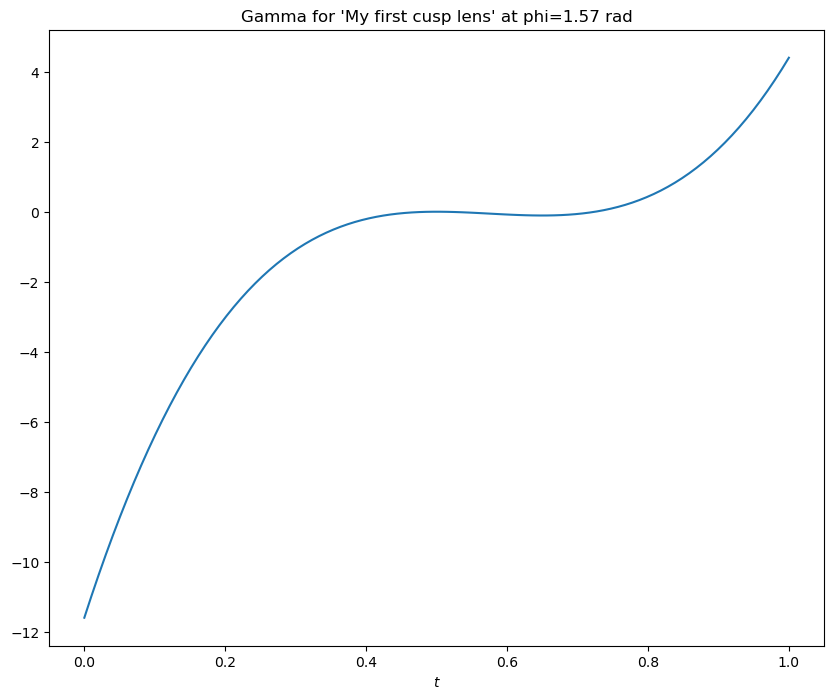

In [7]:
t = np.linspace(0, 1, 100)
theta1 = t * (V1_range[1] - V1_range[0]) + V1_range[0]
theta2 = t * (V2_range[1] - V2_range[0]) + V2_range[0]

fig, ax = plt.subplots(figsize=(10, 8))
plt.plot(t, cl.gamma(phi=phi, theta1=theta1, theta2=theta2))
ax.set_xlabel(r"$t$")
ax.set_title(f"Gamma for '{cl.name}' at phi={phi:.2f} rad")
plt.show()  


---
## **2. Fold**

After a suitable rotation we have the following lensing map (see Gaudi-Petters 2002):

$$u_1 = a\,\theta_1 + \frac{b}{2}\,{\theta_2}^2 + c\,\theta_1\,\theta_2$$
$$u_2 =  \frac{c}{2}\,{\theta_1}^2 + b\,\theta_1\,\theta_2 + \frac{d}{2}\,{\theta_2}^2$$


Here the dimension is:
* $[u_1] = [u_2] = [\theta_1] = [\theta_2] = {\rm rad}$
* $[a] = 1$
* $[b] = {\rm rad}^{-1}$
* $[c] = {\rm rad}^{-1}$
* $[d] = {\rm rad}^{-1}$


**The Jacobian matrix**

$$A = \left(\begin{array}{ll}
    a + c\,\theta_2                     & b\,\theta_2 + c\,\theta_1 \\
    b\,\theta_2 + c\,\theta_1           & b\,\theta_1 + d\,\theta_2
\end{array}\right)$$


**Introducing dimensionless variables**

Introduce:
$$d =: \frac{1}{\theta_*}$$
Now $\theta_*$ defines the angular the scale of the fold, $[\theta_*] = {\rm rad}$.

Introduce dimensionless variables:
$$V_A:=\frac{\theta_A}{\theta_*}$$
$$U_A:=\frac{\theta_A}{\theta_*}$$
$$A:=a$$
$$B:=b\,\theta_*$$
$$C:=c\,\theta_*$$

The lensing equation takes the form of:


$$U_1 = A\,V_1 + \frac{B}{2}\,{V_2}^2 + C\,V_1\,V_2$$
$$U_2 =  \frac{C}{2}\,{V_1}^2 + B\,V_1\,V_2 + {V_2}^2$$

### **2.1 Define the FoldLens class**

In [ ]:
class FoldLens(AbstractLens):
    def __init__(self, *, a: float, b: float, c: float, d: float = 1., name: str = "Fold Lens") -> None:
        self.a = a
        self.b = b
        self.c = c
        self.d = d
        self.name = name
        return
    

    def lensing_map(self, theta1: np.typing.NDArray, theta2: np.typing.NDArray) -> Any:
        u1 = self.a * theta1 + self.b / 2 * theta2**2 + self.c * theta1 * theta2
        u2 = self.c / 2 * theta1**2 + self.b * theta1 * theta2 + self.d / 2 * theta2**2
        return u1, u2
    

    def A(self, theta1: float, theta2: float) -> np.typing.NDArray:
        return np.array(
            (self.a + self.c * theta2,            self.b * theta2 + self.c * theta1),
            (self.b * theta2 + self.c * theta1,   self.b * theta1 + self.d * theta2))
    

    def detA_using_A(self, theta1: np.typing.NDArray | float,  theta2: np.typing.NDArray | float) -> np.typing.NDArray | float:
        return np.linalg.det(self.A(theta1, theta2))
    

    def detA(self, theta1: np.typing.NDArray, theta2: np.typing.NDArray) -> Any:
        return (self.a + self.c * theta2) * (self.b * theta1 + self.d * theta2) - (self.b * theta2 + self.c * theta1)**2
    

    def gamma(self, phi: float, theta1: np.typing.NDArray, theta2: np.typing.NDArray) -> Any:
        u1, u2 = self.lensing_map(theta1, theta2)
        gamma = np.cos(phi) * u1 + np.sin(phi) * u2
        return gamma    

### **2.2 Set up a lens and make a contour plot**

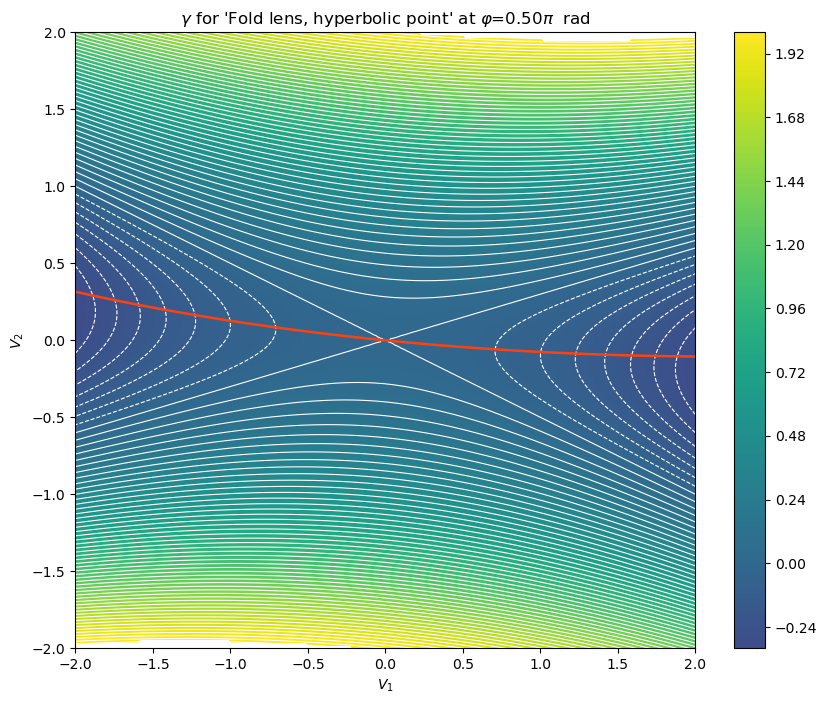

In [9]:
# -----------------------------
#   Define the lensing setup 
# -----------------------------

# --- Define the lens ---
cl = FoldLens(a=1., b=0.1, c=-0.15, d=1., name="Fold lens, hyperbolic point")

# --- Incidence angle of the gradient ---
# 0.0 * np.pi = horizontal gradient / vertical stripe
# 0.5 * np.pi = vertical gradient / horizontal stripe
# 0.25 * np.pi = diagonal gradient / diagonal stripe, orthogonal to the gradient direction
phi = 0.5 * np.pi

# --- Clamping interval for gamma ---
lo, hi = (-1., 2.)

# --- Define the grid of V1 and V2 ---
V1_range = (-2., 2.)
N_V1 = 200
V2_range = (-2., 2.)
N_V2 = 200
V1, V2 = np.meshgrid(np.linspace(*V1_range, N_V1), np.linspace(*V2_range, N_V2))


# ----------------------------------------------------------------------------------------------------------------------
#   Make the plot of gamma on the lens plane, with contours of gamma and the critical curve (detA=0) in the same plot.
# ----------------------------------------------------------------------------------------------------------------------

# --- Compute gamma on the grid ---
gamma = cl.gamma(phi=phi, theta1=V1, theta2=V2)

clamped_gamma = np.empty_like(gamma)    # clamped to the range [lo, hi]
for i in range(gamma.shape[0]):
    for j in range(gamma.shape[1]):
        clamped_gamma[i, j] = clamp(gamma[i, j], lo=lo, hi=hi)

# --- Make the plot ---
fig, ax = plt.subplots(figsize=(10, 8))
plt.contourf(V1, V2, clamped_gamma, levels=300, cmap=mpl.colormaps.get_cmap('viridis'), norm=mpl.colors.Normalize(vmin=lo, vmax=hi))
plt.colorbar()
plt.contour(V1, V2, gamma, levels=80, colors='white', linewidths=(0.8,))
critical_contour = plt.contour(V1, V2, cl.detA(V1, V2), levels=np.array([0.]), colors='xkcd:orangered', linewidths=(1.8,))
ax.set_xlabel(r"$V_1$")
ax.set_ylabel(r"$V_2$")
ax.set_title(r"$\gamma$" + f" for '{cl.name}' at " + r"$\varphi$" + f"={phi/(np.pi):.2f}" + r"$\pi$  rad")
plt.show()  

The source plane and the caustic

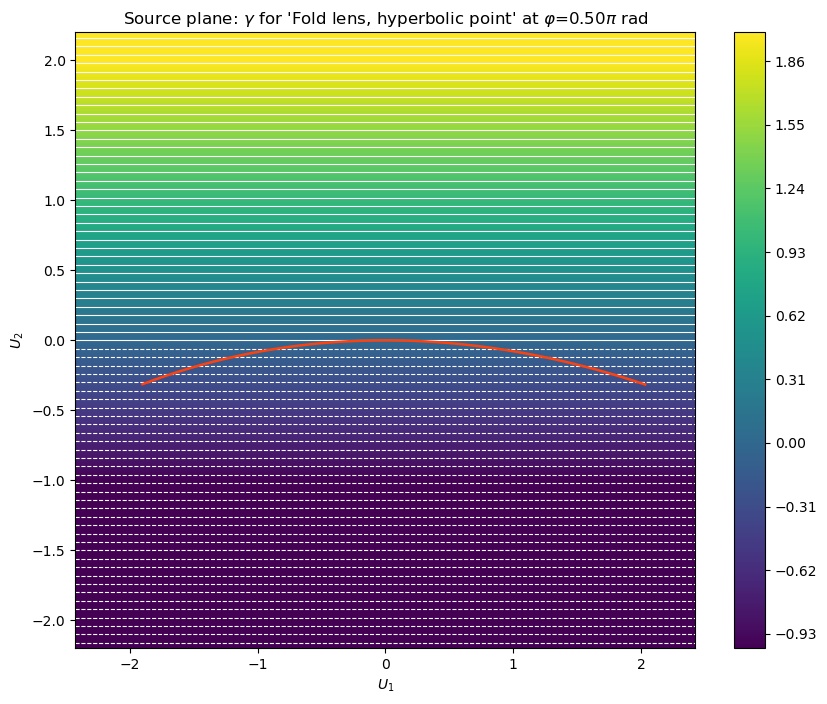

In [10]:
# ---------------------------------------
#   Make the second plot: source plane
# ---------------------------------------

# --- First: extract the critical curve ---
level_set = critical_contour.allsegs[0]     # full level set as a list consisting of many paths (arrays of points)
x_coords = []
y_coords = []
for path in level_set:      # iterate over the paths (connected components of the level set) and extend the list of coordinates
    x_coords.extend(path[:, 0])
    y_coords.extend(path[:, 1])
    
crtitcal_curve = np.stack([np.array(x_coords), np.array(y_coords)], axis=-1)     # make a (N, 2) array

# --- Map the critical curve to the source plane, obraining this way the caustic ---
caustic_x, caustic_y = cl.lensing_map(crtitcal_curve[:, 0], crtitcal_curve[:, 1])
caustic = np.stack([caustic_x, caustic_y], axis=1)      # make a (N, 2) array

# --- Pick automatically the ranges for the plot on the source plane ---

# # Take the four corners of the plot on the lens plane
# corner00 = [V1_range[0], V2_range[0]]
# corner01 = [V1_range[0], V2_range[1]]
# corner10 = [V1_range[1], V2_range[0]]
# corner11 = [V1_range[1], V2_range[1]]
# corners = np.stack([corner00, corner01, corner10, corner11], axis=0)     # make a (4, 2) array

# # Map them 
# pt_source_plane_U1, pt_source_plane_U2 = cl.lensing_map(corners[:, 0], corners[:, 1])
# pt_source_plane = np.stack([pt_source_plane_U1, pt_source_plane_U2], axis=1)    # make a (N, 2) array

# # Pick the range on the source plane
# U1_range = [min(pt_source_plane[:, 0]), max(pt_source_plane[:, 0])]
# U2_range = [min(pt_source_plane[:, 1]), max(pt_source_plane[:, 1])]

# --- Ranges containing the caustic segment ---
U1_range = [min(caustic_x), max(caustic_x)]
U2_range = [min(caustic_y), max(caustic_y)]

# --- Extend the ranges a little bit ---
U1_len = U1_range[1] - U1_range[0]
U2_len = U2_range[1] - U2_range[0]

U1_range = [U1_range[0] - 0.1 * U1_len, U1_range[1] + 0.1 * U1_len]
U2_range = [U2_range[0] - 0.1 * U2_len, U2_range[1] + 0.1 * U2_len]

# --- Extend the ranges again to make them symmetric around zero ---
U1_max_abs = max(abs(U1_range[0]), abs(U1_range[1]))
U2_max_abs = max(abs(U2_range[0]), abs(U2_range[1]))
U1_range = [-U1_max_abs, U1_max_abs]
U2_range = [-U2_max_abs, U2_max_abs]

U2_range = [-2.2, 2.2]    # for the fold lens, the caustic is very elongated in the U2 direction,
                        # so we just pick a fixed range for U2 to make the plot more informative.


# --- Prepare the mesh grid ---
N_U1, N_U2 = (200, 200)     # number of points in the grid on the source plane
U1, U2 = np.meshgrid(np.linspace(*U1_range, N_U1), np.linspace(*U2_range, N_U2))

# --- The Gamma function ---
gamma_lens = U1 * np.cos(phi) + U2 * np.sin(phi)
clamped_gamma_lens = np.empty_like(gamma_lens)
for i in range(gamma_lens.shape[0]):
    for j in range(gamma_lens.shape[1]):
        clamped_gamma_lens[i, j] = clamp(gamma_lens[i, j], lo=lo, hi=hi)

# --- Make the plot ---
fig, ax = plt.subplots(figsize=(10, 8))
plt.contourf(U1, U2, clamped_gamma_lens, levels=300, cmap=mpl.colormaps.get_cmap('viridis'), norm=mpl.colors.Normalize(vmin=lo, vmax=hi))
plt.colorbar()
plt.contour(U1, U2, gamma_lens, levels=80, colors='white', linewidths=(0.8,))
plt.plot(caustic[:, 0], caustic[:, 1], color='xkcd:orangered', linewidth=1.8)
ax.set_xlabel(r"$U_1$")
ax.set_ylabel(r"$U_2$")
ax.set_title(r"Source plane: $\gamma$" + f" for '{cl.name}' at " + r"$\varphi$" + f"={phi/(np.pi):.2f}" + r"$\pi$ rad")
plt.show()  # In the end, it was all just for plt.show()


---
## **Scratch notes**

In [11]:
fff1 = [1, 2, 3, 4]
fff2 = [0, 2, 2, -1]

np.stack([fff1, fff2], axis=-1).shape

(4, 2)

Plotting the determinan $\det A$ and the critical curve $\det A =0$

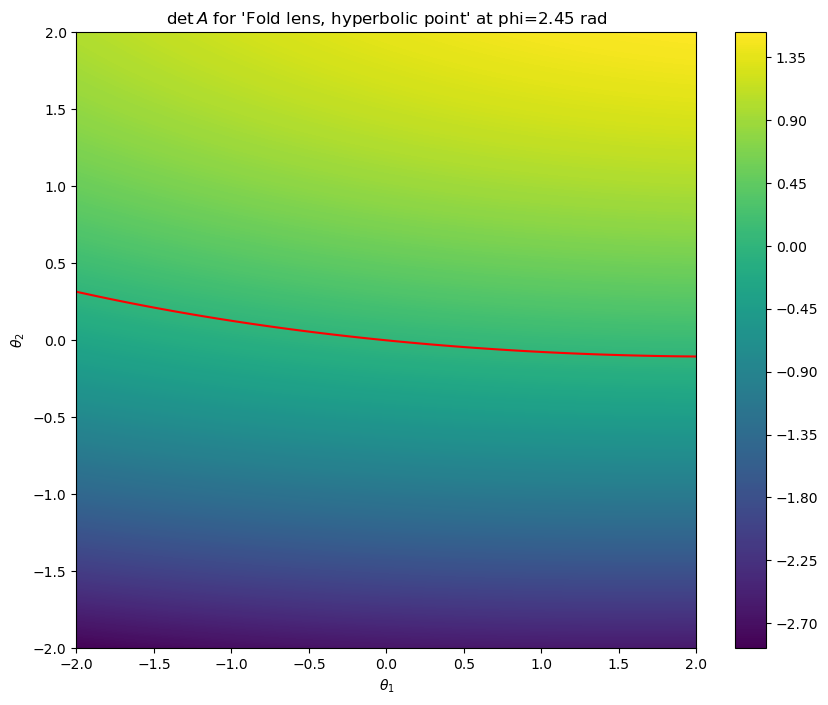

In [12]:
V1_range = (-2., 2.)
N_V1 = 200
V2_range = (-2., 2.)
N_V2 = 200

phi =  np.pi * 0.78

V1, V2 = np.meshgrid(np.linspace(*V1_range, N_V1), np.linspace(*V2_range, N_V2))

fig, ax = plt.subplots(figsize=(10, 8))
plt.contourf(V1, V2, cl.detA(V1, V2), levels=300)
plt.colorbar()
plt.contour(V1, V2, cl.detA(V1, V2), levels=[0.], colors=('red',))
ax.set_xlabel(r"$\theta_1$")
ax.set_ylabel(r"$\theta_2$")
ax.set_title(r"$\det A$" + f" for '{cl.name}' at phi={phi:.2f} rad")
plt.show()  